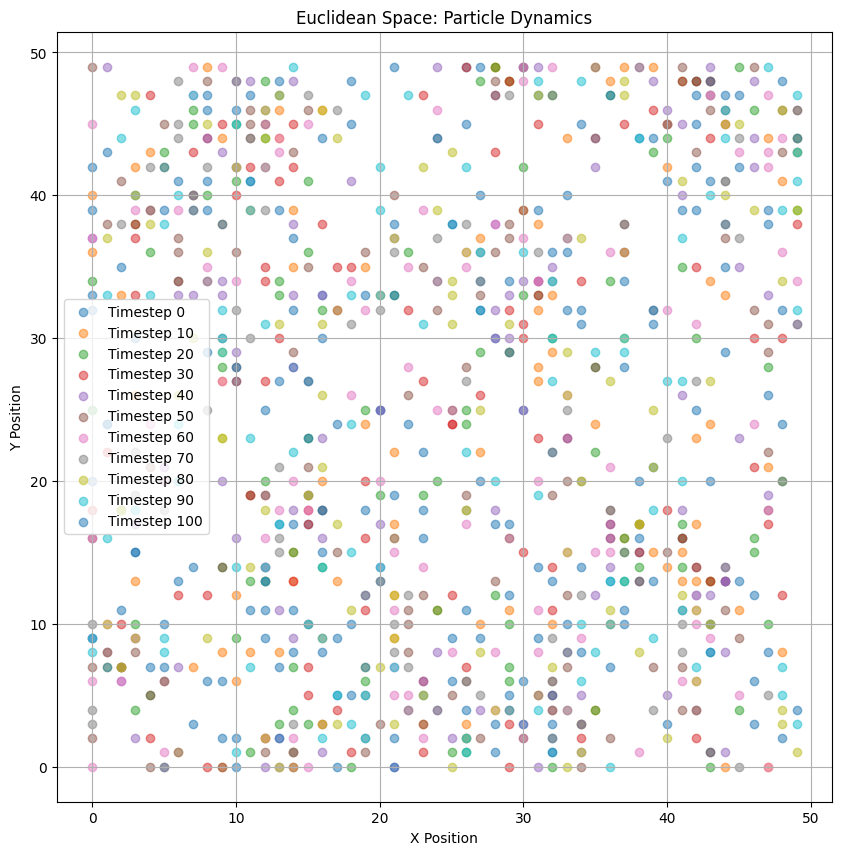

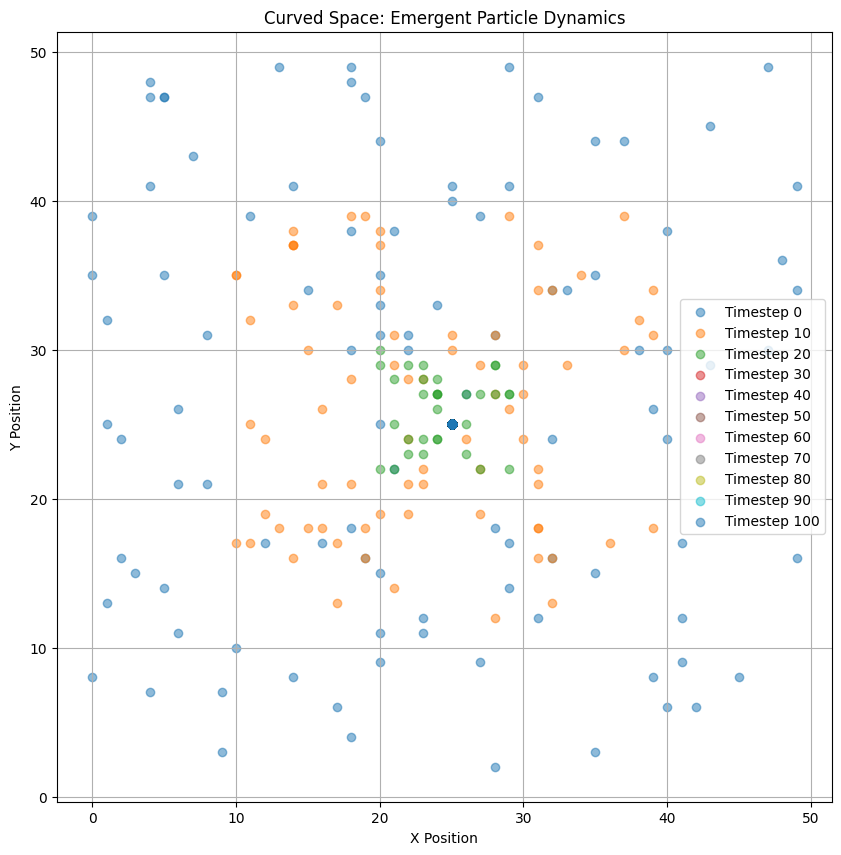

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Constants
GRID_SIZE = 50  # Size of the 2D grid
NUM_PARTICLES = 100  # Number of particles
TIMESTEPS = 100  # Simulation time
CURVATURE_SCALE = 0.1  # Curvature influence

# Initialize particle positions
def initialize_particles(num_particles, grid_size):
    return np.random.randint(0, grid_size, size=(num_particles, 2))

# Euclidean interaction (simple distance-based movement)
def euclidean_interaction(positions, grid_size):
    distances = cdist(positions, positions)
    # Minimal interactions: Move randomly
    move = np.random.randint(-1, 2, size=positions.shape)
    new_positions = positions + move
    return np.clip(new_positions, 0, grid_size - 1)

# Curved space interaction (potential-based movement)
def curved_interaction(positions, grid_size, curvature_scale):
    center = np.array([grid_size // 2, grid_size // 2])  # "Curvature center"
    distances_to_center = cdist(positions, [center]).flatten()
    curvature_potential = -curvature_scale * distances_to_center
    # Attraction toward center and clustering
    gradient = (center - positions) / np.expand_dims(distances_to_center + 1e-9, axis=1)
    movement = gradient + np.random.normal(scale=0.1, size=positions.shape)
    new_positions = positions + np.round(movement).astype(int)
    return np.clip(new_positions, 0, grid_size - 1)

# Run simulation
def run_simulation(interaction_func, grid_size, num_particles, timesteps, curvature_scale=None):
    positions = initialize_particles(num_particles, grid_size)
    history = [positions.copy()]

    for t in range(timesteps):
        if curvature_scale:
            positions = interaction_func(positions, grid_size, curvature_scale)
        else:
            positions = interaction_func(positions, grid_size)
        history.append(positions.copy())

    return history

# Plot results
def plot_simulation(history, title):
    plt.figure(figsize=(10, 10))
    for t, positions in enumerate(history[::10]):  # Plot every 10 timesteps
        plt.scatter(positions[:, 0], positions[:, 1], alpha=0.5, label=f"Timestep {t * 10}")
    plt.title(title)
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
if __name__ == "__main__":
    # Euclidean space simulation
    euclidean_history = run_simulation(euclidean_interaction, GRID_SIZE, NUM_PARTICLES, TIMESTEPS)
    plot_simulation(euclidean_history, "Euclidean Space: Particle Dynamics")

    # Curved space simulation
    curved_history = run_simulation(curved_interaction, GRID_SIZE, NUM_PARTICLES, TIMESTEPS, CURVATURE_SCALE)
    plot_simulation(curved_history, "Curved Space: Emergent Particle Dynamics")


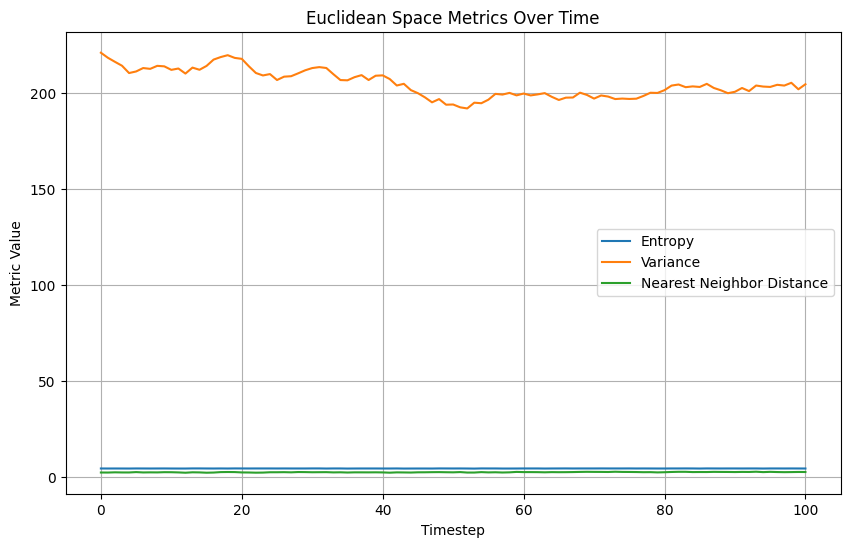

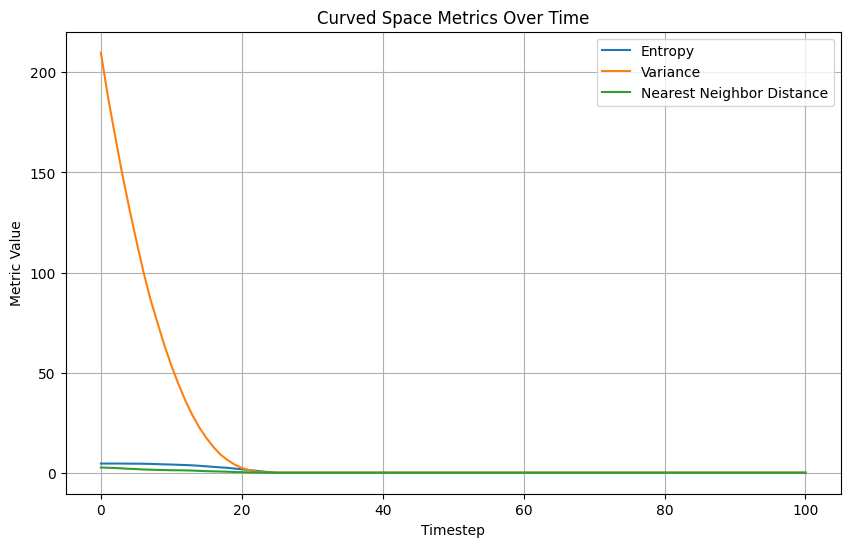

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import entropy

# Constants
GRID_SIZE = 50  # Size of the 2D grid
NUM_PARTICLES = 100  # Number of particles
TIMESTEPS = 100  # Simulation time
CURVATURE_SCALE = 0.1  # Curvature influence

# Initialize particle positions
def initialize_particles(num_particles, grid_size):
    return np.random.randint(0, grid_size, size=(num_particles, 2))

# Euclidean interaction (simple distance-based movement)
def euclidean_interaction(positions, grid_size):
    move = np.random.randint(-1, 2, size=positions.shape)
    new_positions = positions + move
    return np.clip(new_positions, 0, grid_size - 1)

# Curved space interaction (potential-based movement)
def curved_interaction(positions, grid_size, curvature_scale):
    center = np.array([grid_size // 2, grid_size // 2])  # "Curvature center"
    distances_to_center = cdist(positions, [center]).flatten()
    curvature_potential = -curvature_scale * distances_to_center
    gradient = (center - positions) / np.expand_dims(distances_to_center + 1e-9, axis=1)
    movement = gradient + np.random.normal(scale=0.1, size=positions.shape)
    new_positions = positions + np.round(movement).astype(int)
    return np.clip(new_positions, 0, grid_size - 1)

# Run simulation
def run_simulation(interaction_func, grid_size, num_particles, timesteps, curvature_scale=None):
    positions = initialize_particles(num_particles, grid_size)
    history = [positions.copy()]

    for t in range(timesteps):
        if curvature_scale:
            positions = interaction_func(positions, grid_size, curvature_scale)
        else:
            positions = interaction_func(positions, grid_size)
        history.append(positions.copy())

    return history

# Metrics calculation
def calculate_metrics(history, grid_size):
    entropy_values = []
    variance_values = []
    nearest_neighbor_distances = []

    for positions in history:
        # Calculate particle density histogram
        hist, _, _ = np.histogram2d(positions[:, 0], positions[:, 1], bins=grid_size, range=[[0, grid_size], [0, grid_size]])
        hist_flat = hist.flatten() + 1e-9  # Add small value to avoid log(0)

        # Entropy
        entropy_values.append(entropy(hist_flat))

        # Variance (spread of particles)
        variance_values.append(np.var(positions, axis=0).mean())

        # Nearest-neighbor distance
        if len(positions) > 1:
            distances = cdist(positions, positions)
            np.fill_diagonal(distances, np.inf)  # Ignore self-distance
            nearest_neighbors = np.min(distances, axis=1)
            nearest_neighbor_distances.append(np.mean(nearest_neighbors))
        else:
            nearest_neighbor_distances.append(0)

    return entropy_values, variance_values, nearest_neighbor_distances

# Plot metrics
def plot_metrics(metrics, title, metric_names):
    plt.figure(figsize=(10, 6))
    for metric, name in zip(metrics, metric_names):
        plt.plot(metric, label=name)
    plt.title(title)
    plt.xlabel("Timestep")
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
if __name__ == "__main__":
    # Euclidean space simulation
    euclidean_history = run_simulation(euclidean_interaction, GRID_SIZE, NUM_PARTICLES, TIMESTEPS)
    euclidean_entropy, euclidean_variance, euclidean_nn_dist = calculate_metrics(euclidean_history, GRID_SIZE)

    # Curved space simulation
    curved_history = run_simulation(curved_interaction, GRID_SIZE, NUM_PARTICLES, TIMESTEPS, CURVATURE_SCALE)
    curved_entropy, curved_variance, curved_nn_dist = calculate_metrics(curved_history, GRID_SIZE)

    # Plot metrics for Euclidean space
    plot_metrics(
        [euclidean_entropy, euclidean_variance, euclidean_nn_dist],
        "Euclidean Space Metrics Over Time",
        ["Entropy", "Variance", "Nearest Neighbor Distance"]
    )

    # Plot metrics for Curved space
    plot_metrics(
        [curved_entropy, curved_variance, curved_nn_dist],
        "Curved Space Metrics Over Time",
        ["Entropy", "Variance", "Nearest Neighbor Distance"]
    )

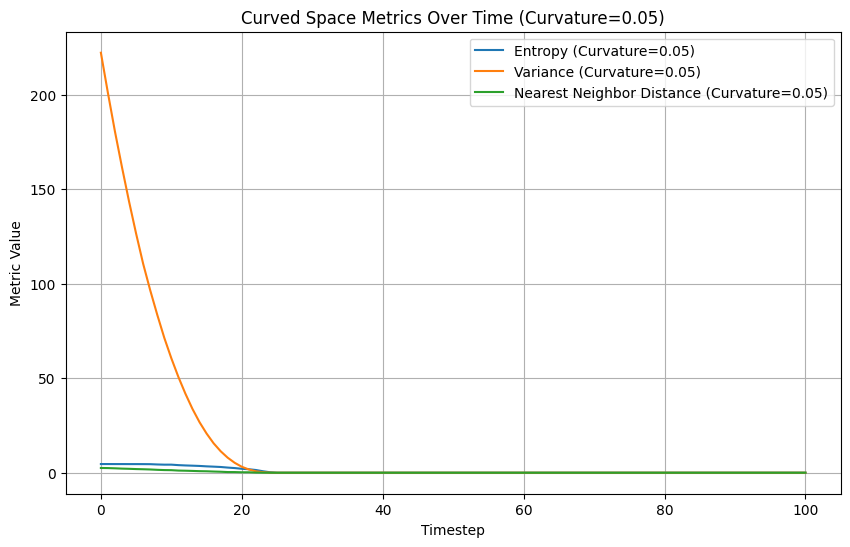

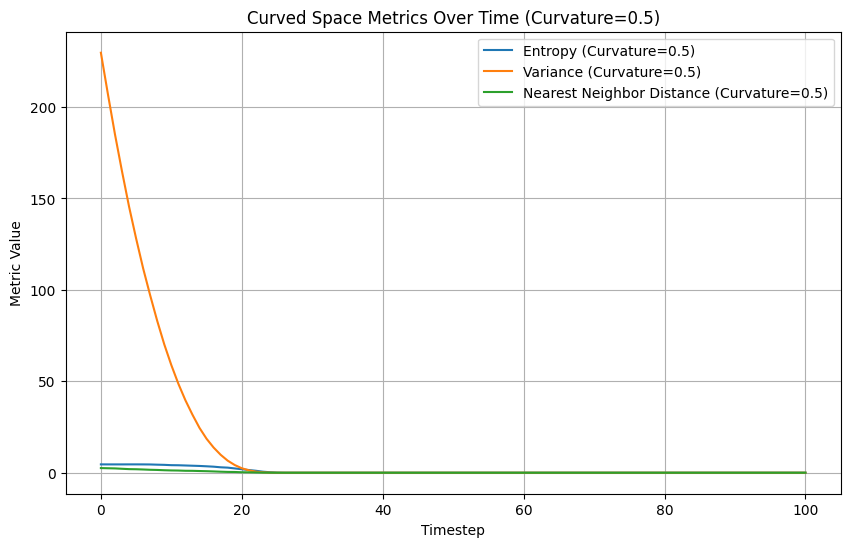

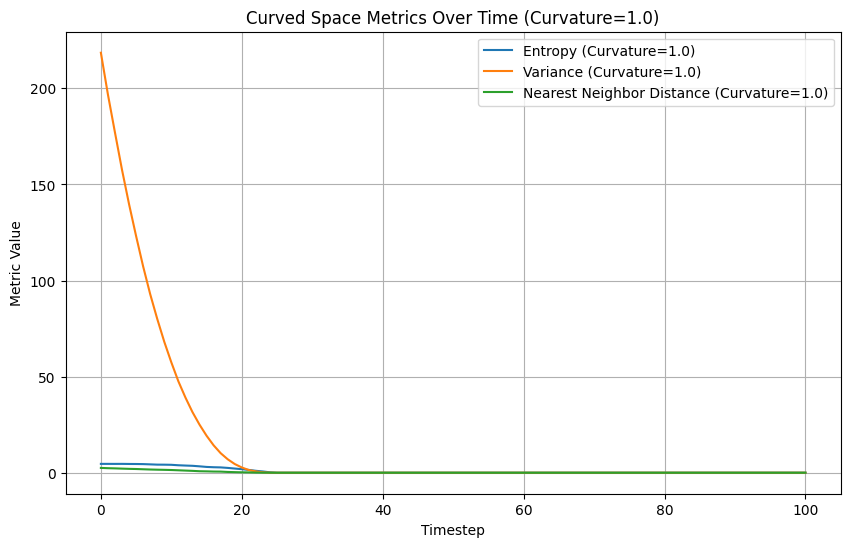

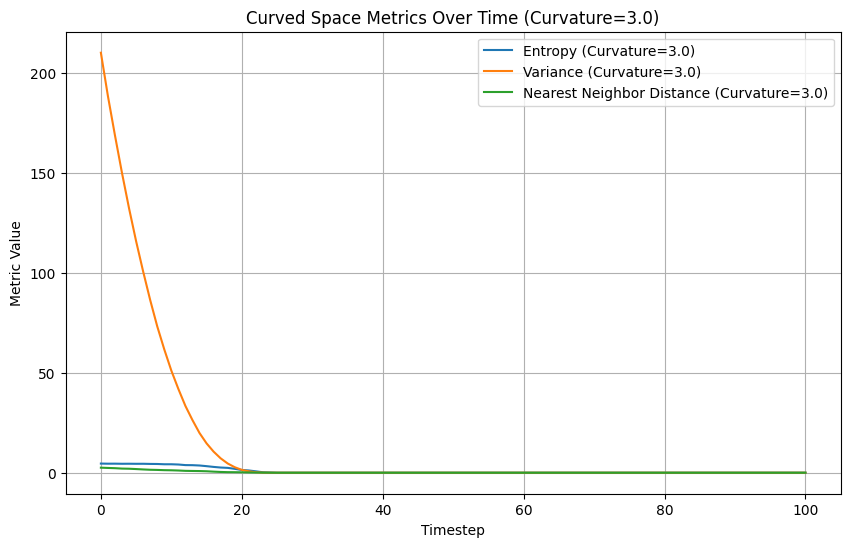

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import entropy

# Constants
GRID_SIZE = 50  # Size of the 2D grid
NUM_PARTICLES = 100  # Number of particles
TIMESTEPS = 100  # Simulation time
CURVATURE_SCALES = [0.05, 0.5, 1.0, 3.0]  # Different curvature strengths

# Initialize particle positions
def initialize_particles(num_particles, grid_size):
    return np.random.randint(0, grid_size, size=(num_particles, 2))

# Euclidean interaction (simple distance-based movement)
def euclidean_interaction(positions, grid_size):
    move = np.random.randint(-1, 2, size=positions.shape)
    new_positions = positions + move
    return np.clip(new_positions, 0, grid_size - 1)

# Curved space interaction (potential-based movement)
def curved_interaction(positions, grid_size, curvature_scale):
    center = np.array([grid_size // 2, grid_size // 2])  # "Curvature center"
    distances_to_center = cdist(positions, [center]).flatten()
    curvature_potential = -curvature_scale * distances_to_center
    gradient = (center - positions) / np.expand_dims(distances_to_center + 1e-9, axis=1)
    movement = gradient + np.random.normal(scale=0.1, size=positions.shape)
    new_positions = positions + np.round(movement).astype(int)
    return np.clip(new_positions, 0, grid_size - 1)

# Run simulation
def run_simulation(interaction_func, grid_size, num_particles, timesteps, curvature_scale=None):
    positions = initialize_particles(num_particles, grid_size)
    history = [positions.copy()]

    for t in range(timesteps):
        if curvature_scale:
            positions = interaction_func(positions, grid_size, curvature_scale)
        else:
            positions = interaction_func(positions, grid_size)
        history.append(positions.copy())

    return history

# Metrics calculation
def calculate_metrics(history, grid_size):
    entropy_values = []
    variance_values = []
    nearest_neighbor_distances = []

    for positions in history:
        # Calculate particle density histogram
        hist, _, _ = np.histogram2d(positions[:, 0], positions[:, 1], bins=grid_size, range=[[0, grid_size], [0, grid_size]])
        hist_flat = hist.flatten() + 1e-9  # Add small value to avoid log(0)

        # Entropy
        entropy_values.append(entropy(hist_flat))

        # Variance (spread of particles)
        variance_values.append(np.var(positions, axis=0).mean())

        # Nearest-neighbor distance
        if len(positions) > 1:
            distances = cdist(positions, positions)
            np.fill_diagonal(distances, np.inf)  # Ignore self-distance
            nearest_neighbors = np.min(distances, axis=1)
            nearest_neighbor_distances.append(np.mean(nearest_neighbors))
        else:
            nearest_neighbor_distances.append(0)

    return entropy_values, variance_values, nearest_neighbor_distances

# Plot metrics
def plot_metrics(metrics, title, metric_names, curvature_scale=None):
    plt.figure(figsize=(10, 6))
    for metric, name in zip(metrics, metric_names):
        plt.plot(metric, label=f"{name} (Curvature={curvature_scale})")
    plt.title(title)
    plt.xlabel("Timestep")
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
if __name__ == "__main__":
    # Run for each curvature scale
    for curvature_scale in CURVATURE_SCALES:
        # Curved space simulation
        curved_history = run_simulation(curved_interaction, GRID_SIZE, NUM_PARTICLES, TIMESTEPS, curvature_scale)
        curved_entropy, curved_variance, curved_nn_dist = calculate_metrics(curved_history, GRID_SIZE)

        # Plot metrics for each curvature scale
        plot_metrics(
            [curved_entropy, curved_variance, curved_nn_dist],
            f"Curved Space Metrics Over Time (Curvature={curvature_scale})",
            ["Entropy", "Variance", "Nearest Neighbor Distance"],
            curvature_scale=curvature_scale
        )